In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import gridspec
import seaborn as sns
import matplotlib as mpl
import matplotlib.patches as patches

import anndata as ad
import scanpy as sc
import cellspec as spc

%matplotlib inline

In [181]:
colors = [
    '#FF1B5E',  # coral
    '#FFDB57',  # yellow
    '#438CFD',  # blue
    '#FF8C00',  # orange
    '#80F15E',  # lime green
    '#03FFFF',  # cyan
    '#5941A9',  # purple
    '#E980FC',  # magenta
    '#1A1A2E',  # navy
    '#F5F0FF',  # lavender white
    '#C17F3E',  # amber brown
]

In [3]:
import matplotlib.font_manager as fm
import os, glob


fm._load_fontmanager(try_read_cache=False)
# Register TeX Gyre Heros if present
for f in glob.glob(os.path.expanduser("~/.local/share/fonts/texgyreheros*.otf")):
    fm.fontManager.addfont(f)

In [4]:
mpl.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["TeX Gyre Heros"],
    "font.size": 12,

    "axes.linewidth": 2.5,
    # Tick marks
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,

    # Tick direction (outward is common in publications)
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# RNA analysis

In [69]:
rna_adata = ad.read_h5ad('../results/old/worm_CapGTA_unsync_pilot_rerun/rna_counts.marker_annotated.h5ad')

In [72]:
rna_adata.obs['marker_sulston_founders'].value_counts()

marker_sulston_founders
AB           33
MS           17
AB|MS        14
E             5
C|D           5
MS|C|D|AB     3
AB|MS|C       3
P4            2
AB|C          1
Name: count, dtype: int64

In [ ]:
# Saving count data
rna_adata.layers["counts"] = rna_adata.X.copy()

In [ ]:
# Normalizing to median total counts
sc.pp.normalize_total(rna_adata)
# Logarithmize the data
sc.pp.log1p(rna_adata)

In [ ]:
sc.pp.highly_variable_genes(rna_adata, n_top_genes=2000, subset=True)
# sc.pl.highly_variable_genes(rna_adata)

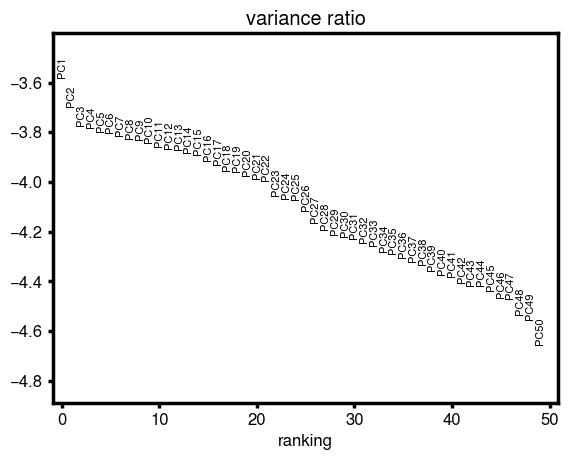

In [ ]:
sc.tl.pca(rna_adata)
sc.pl.pca_variance_ratio(rna_adata, n_pcs=50, log=True)

# DNA Analysis

In [5]:
dna_adata = spc.pp.load_vcf('../results/old/worm_CapGTA_unsync_pilot_rerun/sc_variants_merged.vcf.gz')
dna_adata

Loading VCF: 12405245 sites [03:36, 57293.59 sites/s]
/loc/scratch/53592609/ipykernel_12579/1447630755.py:1: UserWarning: Found 2692 duplicate variant records in VCF (same CHROM-POS-REF>ALT). Kept first occurrence of each. Consider deduplicating your VCF with: bcftools norm -d exact input.vcf.gz -Oz -o output.vcf.gz
  dna_adata = spc.pp.load_vcf('../results/old/worm_CapGTA_unsync_pilot_rerun/sc_variants_merged.vcf.gz')


Skipped 9851681 sites with missing ALT alleles
Building matrices for 2550872 sites × 83 samples...
Done! Loaded 2550872 sites × 83 samples


AnnData object with n_obs × n_vars = 83 × 2550872
    var: 'chrom', 'pos'
    uns: 'vcf_source', 'n_variants', 'n_cells'
    layers: 'DP', 'AD'

In [6]:
## Filter out non snps
spc.pp.filter_to_snps(dna_adata, inplace=True)

In [13]:
spc.pp.annotate_contexts(dna_adata, fasta_path='../data/reference/worm_GCA_028201515.1_STAR/GCA_028201515.1_genomic_renamed.fna')
dna_adata.var

Annotating trinuc contexts: 100%|██████████| 2382816/2382816 [00:21<00:00, 108948.02 sites/s]


,chrom,pos,anc,der,trinuc_type
I-584-A>C,I,584,TAC,TCC,GTA>GGA
I-592-T>G,I,592,CTA,CGA,CTA>CGA
I-770-C>A,I,770,GCC,GAC,GCC>GAC
I-818-C>G,I,818,GCC,GGC,GCC>GGC
I-848-A>T,I,848,AAG,ATG,CTT>CAT
...,...,...,...,...,...
X-17738477-A>G,X,17738477,TAA,TGA,TTA>TCA
X-17738479-A>G,X,17738479,AAG,AGG,CTT>CCT
X-17738481-A>T,X,17738481,GAC,GTC,GTC>GAC
X-17738755-C>A,X,17738755,CCT,CAT,CCT>CAT


In [14]:
dna_adata.var['tot_depth_bulk'] = np.ravel(dna_adata.layers['DP'].sum(axis=0))

Text(0, 0.5, 'Count of Sites')

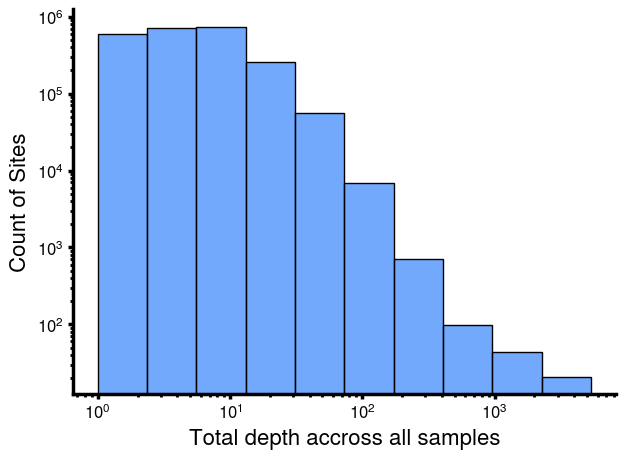

In [15]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(dna_adata.var, x='tot_depth_bulk', 
             alpha=0.75,
             color = colors[2],
             linewidth=1,
             ax=ax,
             log_scale=True,
             bins=10
            )
ax.set_yscale('log')
plt.xlabel("Total depth accross all samples", fontsize=16)
plt.ylabel("Count of Sites", fontsize=16)

In [16]:
dna_adata.obs['SNP_count'] = (dna_adata.layers['AD']>=2).sum(axis=1)
dna_adata.obs

,SNP_count
AAGGCTTGAGGAAGGCTAACACTCCATCGTTGAAGGTTCCACTCA,29828
AAGGCTTGAGGAGGACGAATACTCGGAACTGTAAGGTTCCACTCA,8116
AATGGCAGAGGACGACATTCACTCAGACGAACAAGGGATGGTCTA,54580
AATGGCAGAGGATTCGGTAGACTCGTGTGATGAAGGGACAGCATA,28269
ACCTCGTAAGGAAAGGTGACACTCACAGTAGCAAGGCGGTTGATA,7311
...,...
TATCCGGTAGGACGACATTCACTCAGACACCAAAGGTTGACCACA,27727
TATCCGGTAGGAGGAACCAAACTCAGGTCGTAAAGGCGACCTATA,5267
TGTGGTTGAGGACGCTACTAACTCAGGACATCAAGGGTCCGATTA,8240
TGTGGTTGAGGAGATACCGAACTCAGACACCAAAGGCGACCTATA,51915


Text(0, 0.5, 'Count of Cells')

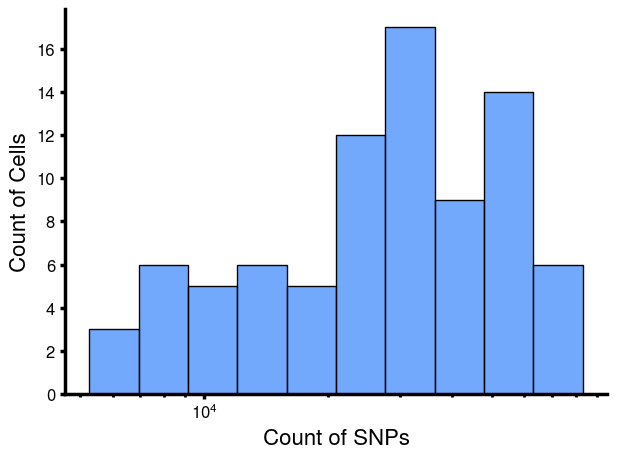

In [17]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(dna_adata.obs, x='SNP_count', 
             alpha=0.75,
             color = colors[2],
             linewidth=1,
             ax=ax,
             log_scale=True,
             bins=10
            )
# ax.set_yscale('log')
plt.xlabel("Count of SNPs", fontsize=16)
plt.ylabel("Count of Cells", fontsize=16)

In [21]:
dna_adata.var['2read_1cell']=np.array((dna_adata.layers['AD']==2).sum(axis=0)==1)[0]
dna_adata.var['>1read_>1cell']=np.array((dna_adata.layers['AD']>=1).sum(axis=0)>1)[0]
dna_adata.var

,chrom,pos,anc,der,trinuc_type,tot_depth_bulk,2read_1cell,>1read_>1cell
I-584-A>C,I,584,TAC,TCC,GTA>GGA,2.0,True,False
I-592-T>G,I,592,CTA,CGA,CTA>CGA,2.0,True,False
I-770-C>A,I,770,GCC,GAC,GCC>GAC,3.0,False,False
I-818-C>G,I,818,GCC,GGC,GCC>GGC,2.0,True,False
I-848-A>T,I,848,AAG,ATG,CTT>CAT,4.0,False,True
...,...,...,...,...,...,...,...,...
X-17738477-A>G,X,17738477,TAA,TGA,TTA>TCA,2.0,True,False
X-17738479-A>G,X,17738479,AAG,AGG,CTT>CCT,2.0,True,False
X-17738481-A>T,X,17738481,GAC,GTC,GTC>GAC,2.0,True,False
X-17738755-C>A,X,17738755,CCT,CAT,CCT>CAT,3.0,False,False


In [26]:
sc_spectrum = spc.tl.compute_spectrum_from_mask(dna_adata, dna_adata.var['2read_1cell'])

Exception ignored in: <function Faidx.__del__ at 0x146c99a09090>
Traceback (most recent call last):
  File "/home/dmullane/micromamba/envs/default_jupyter/lib/python3.10/site-packages/pyfaidx/__init__.py", line 883, in __del__
    self.__exit__()
  File "/home/dmullane/micromamba/envs/default_jupyter/lib/python3.10/site-packages/pyfaidx/__init__.py", line 889, in __exit__
    self.file.close()
AttributeError: 'Faidx' object has no attribute 'file'


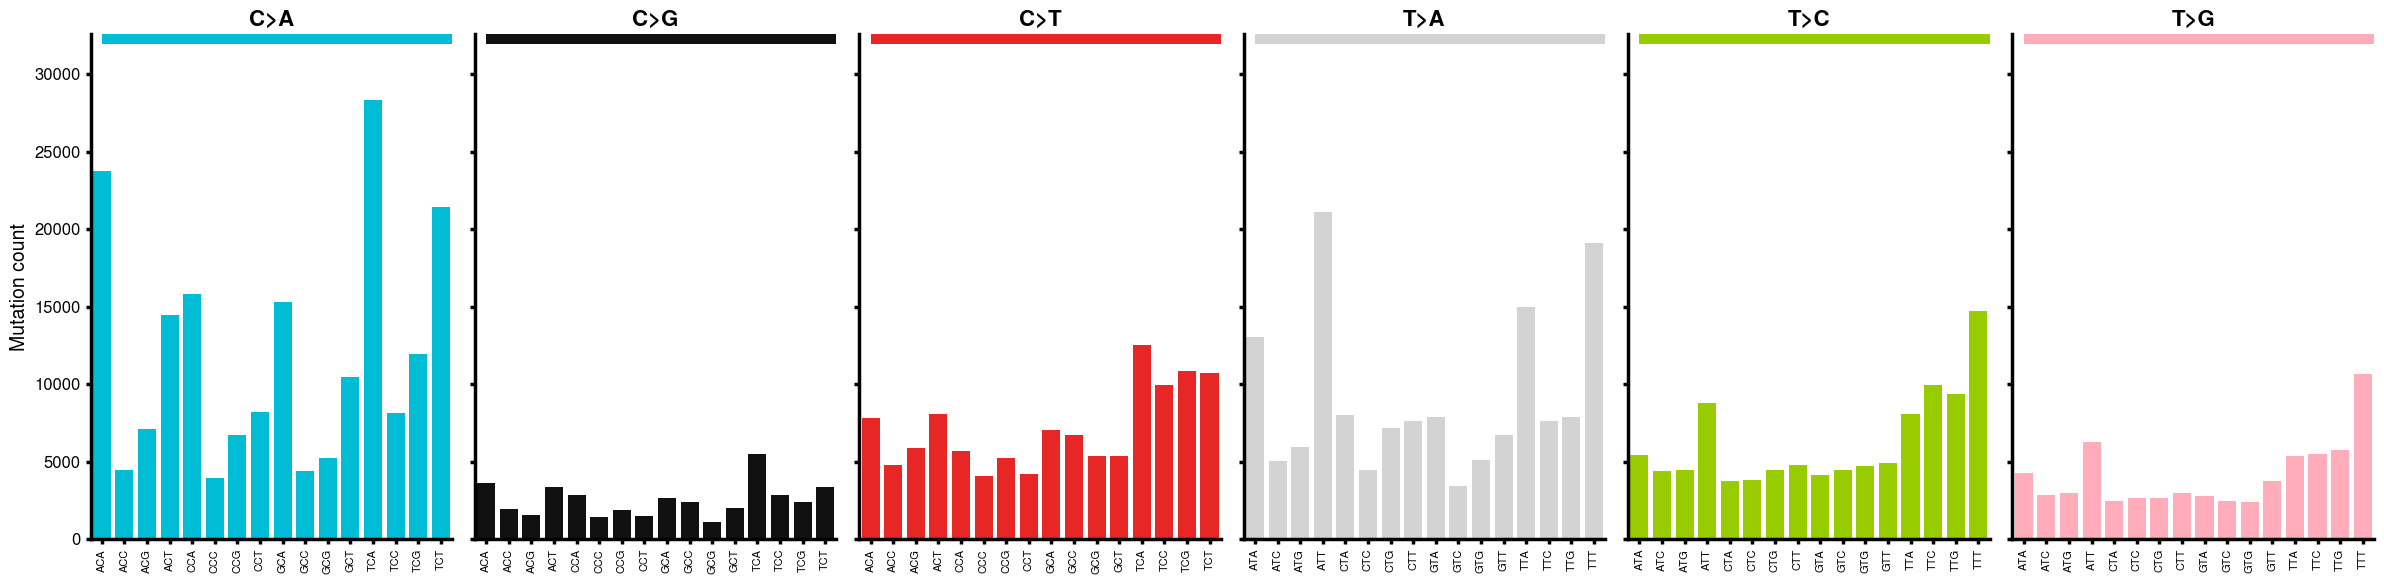

In [27]:
spc.pl.spectrum_from_df(sc_spectrum)

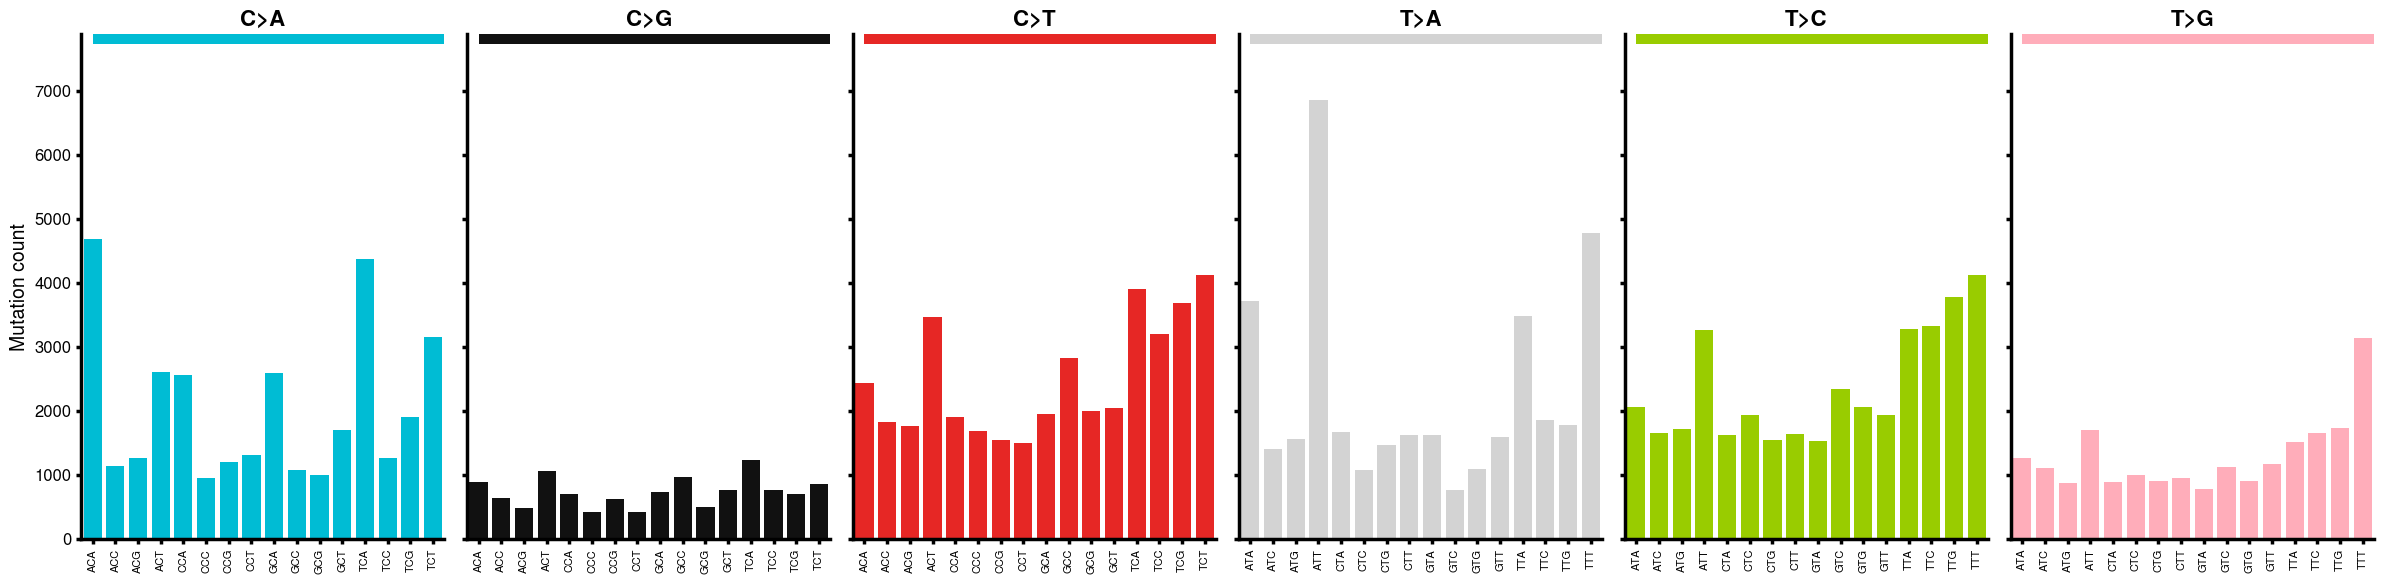

In [29]:
mc_spectrum = spc.tl.compute_spectrum_from_mask(dna_adata, dna_adata.var['>1read_>1cell'])
spc.pl.spectrum_from_df(mc_spectrum)

In [62]:
spectrum = pd.DataFrame(mc_spectrum)

In [66]:
plt.style.use("dark_background")

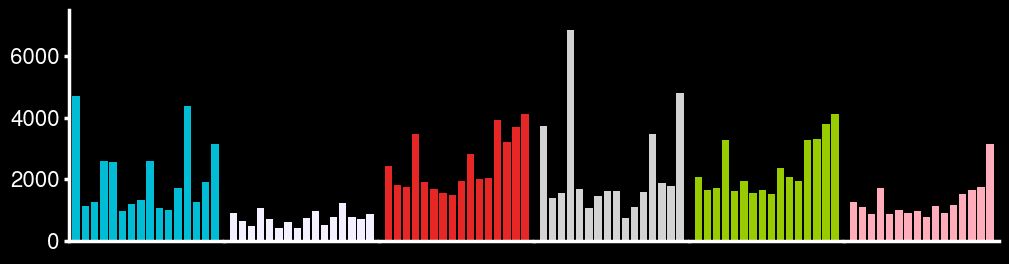

In [68]:
import matplotlib.ticker as mticker
from cellspec.utils.constants import MUTATION_TYPES, MUTATION_COLORS_DARK

# --- knobs to tweak ---
figsize = (12, 3)
bar_width = 0.8
group_padding = 0.5
wspace = 0
left_pad = 0.25
subplot_title_fontsize = 10
ylabel_fontsize = 16
ytick_fontsize = 16
normalize = False
ylim = (0, 7500)
colors = [MUTATION_COLORS_DARK[t] for t in MUTATION_TYPES]
# yticks = [1_500_000, 2_000_000, 2_500_000]
# ----------------------
# spectrum = bg

if normalize and spectrum.sum() > 0:
    spectrum = spectrum / spectrum.sum()

fig, axes = plt.subplots(1, 6, figsize=figsize, sharey=True)

if ylim is not None:
    y_min, y_max = ylim
else:
    y_min, y_max = 0, spectrum.max() * 1.15

for col, mut_type in enumerate(MUTATION_TYPES):
    ax = axes[col]
    contexts = [c for c in spectrum.index if f"{c[1]}>{c[5]}" == mut_type]
    counts = [spectrum.loc[c][0] for c in contexts]

    if col == 0:
        x_pos = np.arange(len(contexts)) + left_pad
        ax.bar(x_pos, counts, color=colors[col], width=bar_width, edgecolor='none')
        ax.set_xlim(-0.5, len(contexts) - 0.5 + left_pad + group_padding)
    else:
        x_pos = np.arange(len(contexts))
        ax.bar(x_pos, counts, color=colors[col], width=bar_width, edgecolor='none')
        ax.set_xlim(-0.5 - group_padding, len(contexts) - 0.5 + group_padding)

    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if col == 0:
        ax.tick_params(axis='y', labelsize=ytick_fontsize)
        # ax.set_ylabel('SBS (thousands)', fontsize=ylabel_fontsize)
        # ax.set_yticks(yticks)
        # ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000000)}'))
    else:
        ax.tick_params(axis='y', left=False, labelleft=False)
        ax.spines['left'].set_visible(False)

plt.subplots_adjust(wspace=wspace)
plt.savefig(f'../../presentation_figures/worm_spectrum.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()
    

### Cell type specific mutation spectra

```
                       P0  (zygote)
                      /   \
                    AB     P1
              (389 cells)  / \
                         EMS  P2
                         / \   / \
                        MS  E C   P3
                       (80)(20)(47)/ \
                                  D   P4
                                 (20) |
                                      Z2/Z3
                                      (germline)
```

In [76]:
dna_adata.obs['sulston_founder'] = rna_adata.obs['marker_sulston_founders']

In [106]:
dna_adata.obs['sulston_founder'].value_counts()

sulston_founder
AB           33
MS           17
AB|MS        14
E             5
C|D           5
MS|C|D|AB     3
AB|MS|C       3
P4            2
AB|C          1
Name: count, dtype: int64

In [117]:
P4_adata = dna_adata[dna_adata.obs['sulston_founder']=='P4',:]
# P4_muts = set(P4_adata.var.loc[np.array((P4_adata.layers['AD']>0).sum(axis=0)>1)[0]].index)

P4_adata.var.loc[np.array((P4_adata.layers['AD']>0).sum(axis=0)>1)[0]].index

Index(['I-100803-A>C', 'I-103625-C>T', 'I-934034-A>T', 'I-2062517-A>T',
       'I-3697124-A>C', 'I-3697127-A>T', 'I-3697131-T>A', 'I-4005372-C>T',
       'I-4005515-G>A', 'I-4005627-A>T',
       ...
       'X-3036138-C>T', 'X-9903250-G>T', 'X-10166043-G>T', 'X-10372950-G>T',
       'X-11800274-T>C', 'X-12038888-A>C', 'X-12038900-C>T', 'X-12353845-C>A',
       'X-15827190-C>T', 'X-16720972-T>A'],
      dtype='object', length=134)

In [118]:
other_adata = dna_adata[dna_adata.obs['sulston_founder']!='P4',:]
        
other_muts = set(other_adata.var.loc[np.array((other_adata.layers['AD']>0).sum(axis=0)>1)[0]].index)

In [172]:
vc = {
    'AB':10,
    'MS':5,
    'E':2,
    'C|D':2,
    'P4':1
}

lineage_split_muts = set()

counts = {}

for lineage in ['AB', 'MS', 'E', 'C|D', 'P4']:
    
    adata = dna_adata[dna_adata.obs['sulston_founder']==lineage,:]
    muts = set(adata.var.loc[np.array((adata.layers['AD']>1).sum(axis=0)>vc[lineage])[0]].index)

    other_adata = dna_adata[dna_adata.obs['sulston_founder']!=lineage,:]
        
    other_muts = set(other_adata.var.loc[np.array((other_adata.layers['AD']>0).sum(axis=0)>10)[0]].index)
    
    lineage_muts = muts - other_muts
    
    lineage_split_muts.update(lineage_muts)

    print(f"{lineage} : {len(lineage_muts)}")
    
    counts[lineage] = len(lineage_muts)

AB : 45
MS : 42
E : 86
C|D : 110
P4 : 80


In [193]:
pal = {
    'AB': '#240091',
    'MS': '#1f8cff',
    'E': '#ffd756',
    'C|D': '#ff9b6f',
    'P4': '#ff1a5a',
}

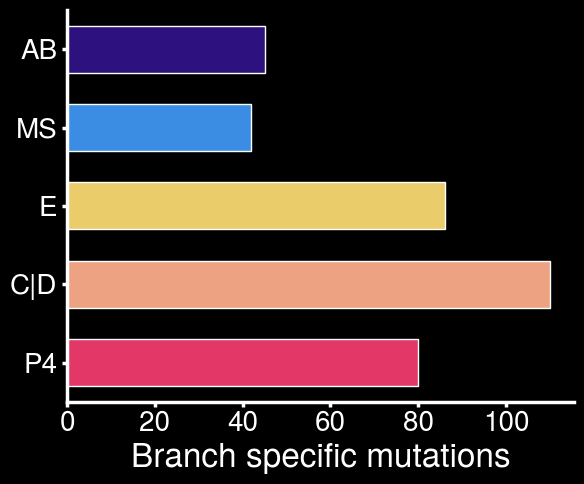

In [194]:


f, ax = plt.subplots(figsize=(6, 5))
sns.despine(f)
sns.barplot(
    y=list(counts.keys()),
    x=list(counts.values()),
    palette=pal,
    hue=list(counts.keys()),
    # alpha=0.75,
    edgecolor="white",
    linewidth=1,
    width=0.6,
)
plt.xlabel('Branch specific mutations', fontsize=24)
# plt.ylabel('Lineage', fontsize=24)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
f.savefig('../../presentation_figures/worm_shared_muts.png', dpi=600, bbox_inches='tight', transparent=True)

In [156]:
adata_sub = dna_adata[:,list(lineage_split_muts)]

In [160]:
adata_sub

View of AnnData object with n_obs × n_vars = 83 × 363
    obs: 'SNP_count', 'sulston_founder'
    var: 'chrom', 'pos', 'anc', 'der', 'trinuc_type', 'tot_depth_bulk', '2read_1cell', '>1read_>1cell'
    uns: 'vcf_source', 'n_variants', 'n_cells'
    layers: 'DP', 'AD'

In [157]:

lineage_split_muts = set()

counts = {}

for lineage in ['AB', 'MS', 'E', 'C|D', 'P4']:
    
    adata = dna_adata[dna_adata.obs['sulston_founder']==lineage,:]
    muts = set(adata.var.loc[np.array((adata.layers['AD']>1).sum(axis=0)>2)[0]].index)

    other_adata = dna_adata[dna_adata.obs['sulston_founder']!=lineage,:]
        
    other_muts = set(other_adata.var.loc[np.array((other_adata.layers['AD']>0).sum(axis=0)>10)[0]].index)
    
    lineage_muts = muts - other_muts
    
    lineage_split_muts.update(lineage_muts)

    print(f"{lineage} : {len(lineage_muts)}")
    
    counts[lineage] = len(lineage_muts)

AB : 14242
MS : 3316
E : 86
C|D : 110
P4 : 0


In [158]:
adata_sub_2 = dna_adata[:,list(lineage_split_muts)]

In [161]:
spc.tl.compute_spectrum(adata_sub_2)

Computing spectrum (key='spectrum'): 100%|██████████| 83/83 [00:00<00:00, 949.93cell/s]
/fh/fast/srivatsan_s/grp/SrivatsanLab/Dustin/cellspec/src/cellspec/tl/spectrum.py:260: ImplicitModificationWarning: Setting element `.obsm['spectrum_spectrum']` of view, initializing view as actual.
  adata.obsm[f"spectrum_{key}"] = spectrum_df


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
AAGGCTTGAGGAAGGCTAACACTCCATCGTTGAAGGTTCCACTCA,33,5,8,9,2,2,2,4,7,3,...,4,4,2,7,5,3,2,9,6,22
AAGGCTTGAGGAGGACGAATACTCGGAACTGTAAGGTTCCACTCA,3,3,2,3,1,1,1,2,1,2,...,0,1,1,0,0,0,1,0,4,6
AATGGCAGAGGACGACATTCACTCAGACGAACAAGGGATGGTCTA,39,15,11,33,29,16,18,16,20,6,...,13,10,6,15,14,12,24,22,24,49
AATGGCAGAGGATTCGGTAGACTCGTGTGATGAAGGGACAGCATA,10,2,1,9,5,3,2,6,4,5,...,3,5,0,2,2,3,9,7,8,12
ACCTCGTAAGGAAAGGTGACACTCACAGTAGCAAGGCGGTTGATA,1,4,2,1,4,3,1,5,1,1,...,0,0,2,1,1,1,3,1,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TATCCGGTAGGACGACATTCACTCAGACACCAAAGGTTGACCACA,22,3,1,8,10,3,1,10,5,5,...,3,6,3,7,3,6,5,10,4,12
TATCCGGTAGGAGGAACCAAACTCAGGTCGTAAAGGCGACCTATA,6,3,0,8,3,0,2,0,0,0,...,0,1,2,0,1,1,3,2,4,5
TGTGGTTGAGGACGCTACTAACTCAGGACATCAAGGGTCCGATTA,4,0,0,3,2,0,0,0,0,0,...,1,3,3,1,2,2,3,1,1,9
TGTGGTTGAGGAGATACCGAACTCAGACACCAAAGGCGACCTATA,26,15,11,24,16,12,10,9,19,11,...,9,6,9,10,8,11,25,24,21,41


/fh/fast/srivatsan_s/grp/SrivatsanLab/Dustin/cellspec/src/cellspec/pl/spectrum.py:248: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_indices in adata.obs.groupby(groupby).groups.items():


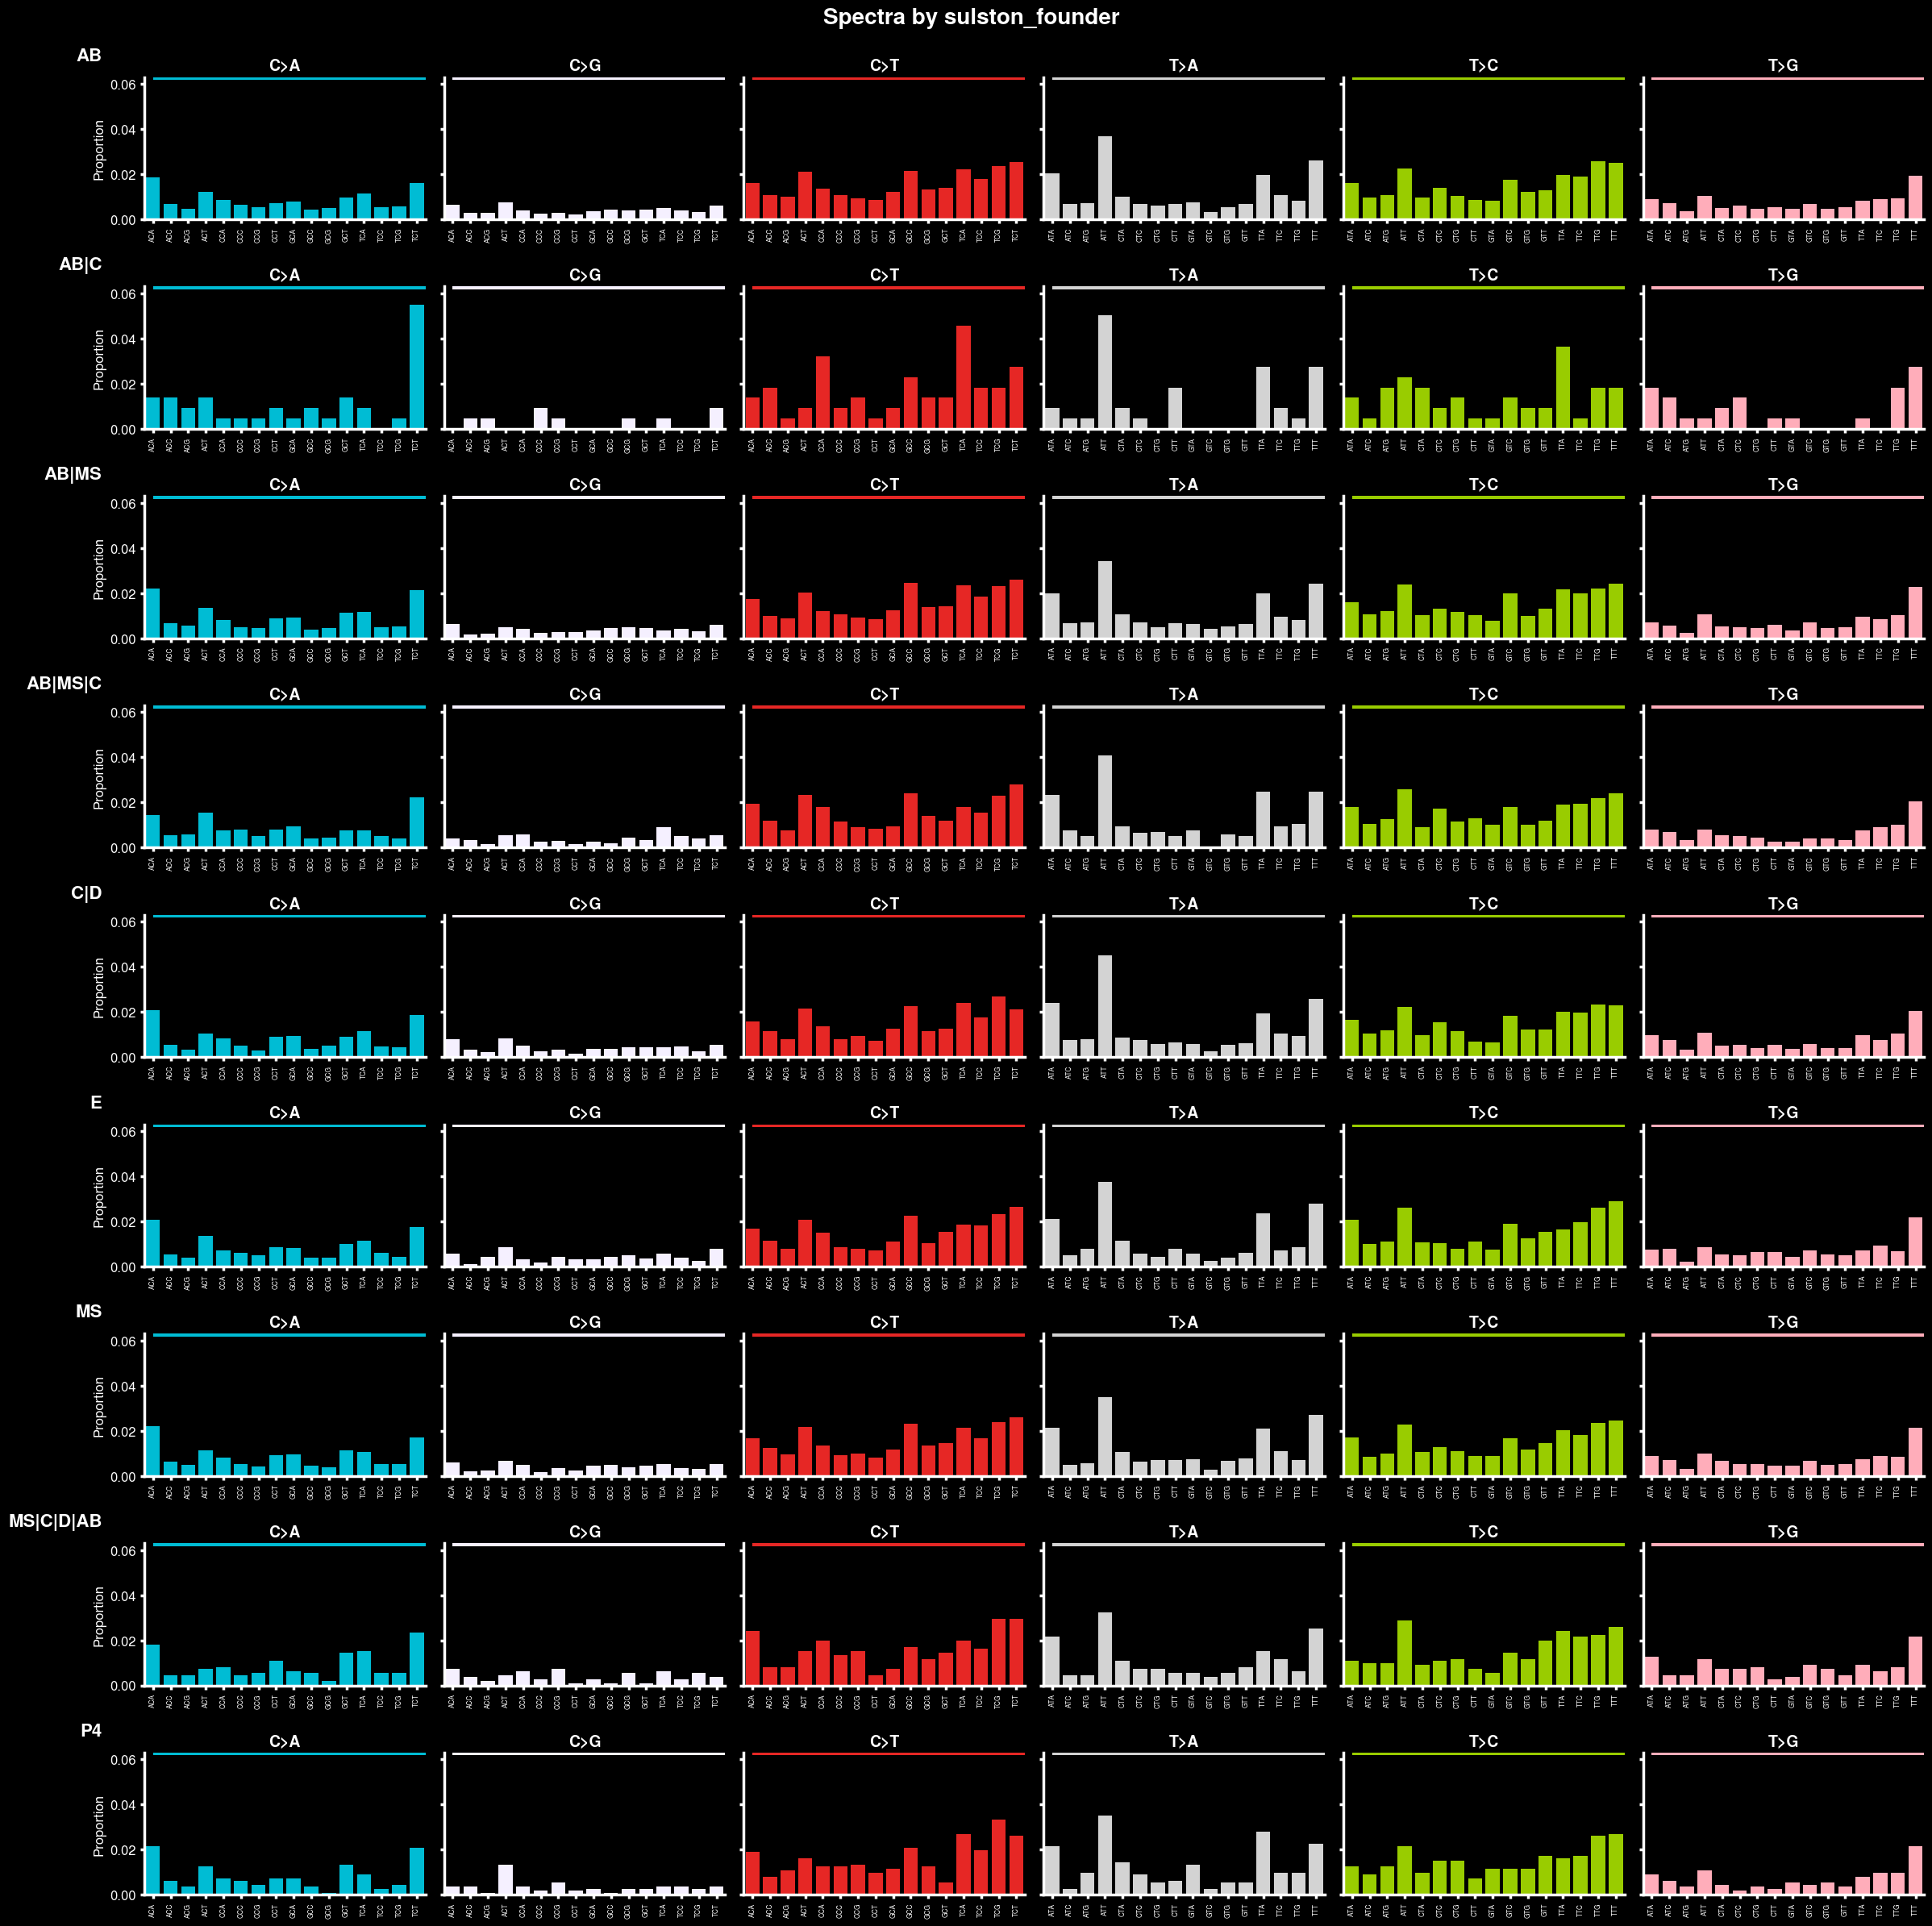

In [170]:
spc.pl.spectrum(adata_sub_2, groupby='sulston_founder', palette='dark', figsize=(24,24), normalize=True)

### PCA of variants

In [32]:

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [33]:
X = dna_adata.X.toarray() if hasattr(dna_adata.X, 'toarray') else adata.X
# Use ALL variants for clustering
X_all = X.copy()

# Convert genotypes for PCA: UNKNOWN → REF (conservative)
X_all[X_all == 2] = 0

# PCA
pca_all = PCA(n_components=min(10, X_all.shape[1]))
X_pca_all = pca_all.fit_transform(X_all)

print(f"PCA on ALL variants:")
print(f"  Shape: {X_pca_all.shape}")
print(f"  Variance explained (first 3 PCs): {pca_all.explained_variance_ratio_[:3]}")

PCA on ALL variants:
  Shape: (83, 10)
  Variance explained (first 3 PCs): [0.02220006 0.02157668 0.02005214]


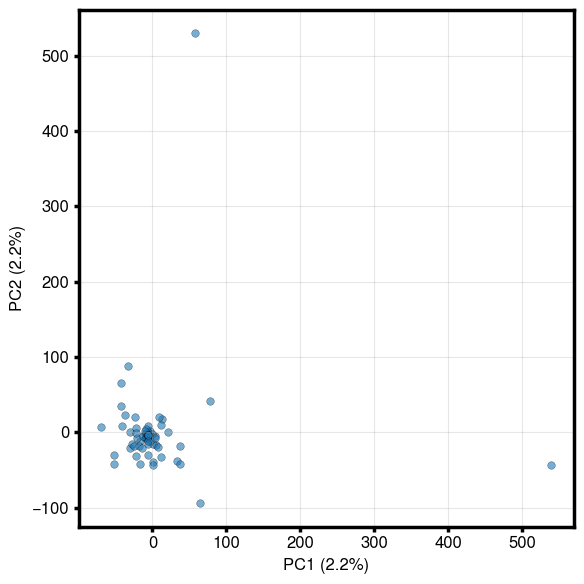

In [35]:
# Visualize PCA on all variants
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(X_pca_all[:, 0], X_pca_all[:, 1], s=30, alpha=0.6, edgecolor='black', linewidth=0.3)

ax.set_xlabel(f'PC1 ({pca_all.explained_variance_ratio_[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_all.explained_variance_ratio_[1]:.1%})', fontsize=12)
# ax.set_title('PCA on ALL Variants', fontsize=14)
# ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()